# Computer Vision 

## Notebook 2 — YOLOv10: Training, Evaluation & Error Analysis

| | |
|---|---|
| **Dataset** | VisioDECT — Scenario-Based Multi-Drone Detection (same as Notebook 1) |
| **Input** | Output of Notebook 1 (`visiodect_yolo/` + `data.yaml`), attached via *Add Input → Your Work* |
| **Model** | YOLOv10-**m** (justified in CONFIG) |

**This notebook covers Tasks for YOLOv10:**

1. CONFIG (every parameter justified — viva requirement)
2. Environment setup + dataset resolution from Notebook 1 output
3. **1-epoch dry run** → wall-time extrapolation vs. Kaggle session budget
4. **Full 50-epoch training** with loss / mAP curves
5. Test-split evaluation: mAP@50, mAP@50:95, Precision, Recall, F1, **FPS** 
6. Error analysis: ≥3 FN, ≥3 FP, misclassifications, per-scenario slicing, failure-pattern summary 
7. Best-checkpoint export to `/kaggle/working/` for cross-model comparison

> **Kaggle setup before running:** Settings → Accelerator = **GPU T4 x2** (we use one), Internet = **On**, and attach Notebook 1's committed output as an input dataset.

## 1. CONFIG

All hyperparameters are declared here with per-line justification. Sources of justification: the assignment's Section 4 sizing/tuning tables and the EDA findings exported by Notebook 1 (`eda_summary.json`).

In [1]:
# =============================== CONFIG ===============================

# ---- model ------------------------------------------------------------
MODEL_WEIGHTS = "yolov10s.pt"
# Justification (assignment §4.1): Notebook 1 exports 14,637 training images,
# which falls in the 8k–20k band -> "m or l". We choose m because:
#   (a) l at imgsz=640 on ~14.6k images is ~260-420 min for 50 epochs (§4.2),
#       leaving little buffer inside one T4 session; m fits comfortably.
#   (b) The dataset has exactly one object per image and 6 visually distinct
#       classes — capacity demand is moderate; l is the fallback only if
#       validation mAP@50:95 plateaus early (checked on the curves below).
# YOLOv10 note for viva: v10 is NMS-free at inference (consistent dual
# assignment: one-to-many head for training, one-to-one head for inference),
# so the classic NMS IoU threshold plays no role at deploy time.

# ---- training schedule --------------------------------------------------
EPOCHS      = 50      # assignment minimum for YOLO models
PATIENCE    = 25      # early stop on mAP@50:95 plateau (§4.3.1 suggests 20-30)
WARMUP_E    = 3       # §4.3.1: 3-5 warmup epochs to avoid unstable early grads
CLOSE_MOSAIC= 10      # §4.3.2: disable mosaic for last 10 epochs -> better box precision

# ---- input / batch ------------------------------------------------------
IMG_SIZE = 640        # EDA (NB1): median box area ~3.6k px^2 (~60x60 -> "medium"),
                      # small-object share 6.6% -> 640 is sufficient as baseline;
                      # 1280 reserved as a smoke test if small-object recall stalls.
BATCH    = 16         # §4.3.1: largest safe batch on T4 at 640 without OOM
LR0      = 0.01       # ultralytics default for batch 16; we did NOT scale it
                      # because we kept the default batch (linear LR scaling rule
                      # only applies when batch deviates from the default).
OPTIMIZER= "auto"     # lets ultralytics pick SGD w/ momentum + cosine-like decay
COS_LR   = True       # smooth decay -> stable final epochs after close_mosaic

# ---- augmentation (mirrors the NB1-justified pipeline; YOLO applies it online)
AUG = dict(
    fliplr=0.5,       # drones are L-R symmetric; orientation not semantic (NB1 #1)
    flipud=0.0,       # sky-above/ground-below layout IS semantic -> excluded (NB1)
    degrees=7.0,      # small camera tilt only; horizon layout meaningful (NB1 #2)
    translate=0.05,   # ±5% translation (NB1 #2)
    scale=0.15,       # ±15% scale jitter ~ NB1's 0.85-1.15 (altitude variation)
    hsv_h=0.010,      # mild hue: sky colour shifts across sunny/cloudy/evening
    hsv_s=0.5,        # (NB1 #3-4: photometric variation is the dataset's main axis)
    hsv_v=0.4,
    mosaic=1.0,       # applied INSIDE the trainer as per assignment guidance,
                      # then disabled by close_mosaic=10 (NB1 excluded it offline
                      # precisely to avoid double-mosaicking)
    mixup=0.0,        # one object/image, balanced classes -> label noise for no gain
    copy_paste=0.0,
)

# ---- inference / evaluation ---------------------------------------------
CONF_EVAL = 0.25      # §4.3.2 operating point for the P/R/F1 report + error analysis
                      # (mAP itself is computed by the validator sweeping confidence)
SEED      = 42        # same seed as Notebook 1 -> full reproducibility

# ---- paths ----------------------------------------------------------------
RUNS_DIR   = "/kaggle/working/runs"
RUN_NAME   = "yolov10m_visiodect"
DATA_YAML  = "/kaggle/working/data.yaml"     # regenerated below to point at the
                                             # (read-only) Notebook-1 input dataset
print(f"CONFIG loaded | model={MODEL_WEIGHTS} | epochs={EPOCHS} | imgsz={IMG_SIZE} "
      f"| batch={BATCH} | seed={SEED}")

CONFIG loaded | model=yolov10s.pt | epochs=50 | imgsz=640 | batch=16 | seed=42


## 2. Environment Setup & Dataset Resolution

We locate Notebook 1's output under `/kaggle/input/` automatically (the attached-dataset folder name varies), then **regenerate `data.yaml`** in `/kaggle/working/` because the copy from Notebook 1 hard-codes `path: /kaggle/working/visiodect_yolo`, which is no longer where the data lives in this session.

In [2]:
%pip install -q -U ultralytics

import os, json, time, random, shutil, yaml
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
from ultralytics import YOLO
import ultralytics

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("ultralytics:", ultralytics.__version__)
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "-")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.87
torch: 2.10.0+cu128 | CUDA: True | Tesla T4


In [3]:
# ---- locate Notebook 1's exported dataset under /kaggle/input --------------
def find_dataset_dir(base="/kaggle/input"):
    hits = []
    for y in Path(base).rglob("data.yaml"):
        d = y.parent
        if (d / "train" / "images").is_dir() and (d / "test" / "images").is_dir():
            hits.append(d)
    if not hits:
        raise FileNotFoundError(
            "Notebook 1 output not found. Use 'Add Input' -> 'Your Work' -> "
            "Notebook 1's committed output, then re-run.")
    return hits[0]

DATASET_DIR = find_dataset_dir()
print("Dataset dir :", DATASET_DIR)

# class names come from Notebook 1's yaml (single source of truth)
nb1_yaml    = yaml.safe_load((DATASET_DIR / "data.yaml").read_text())
CLASS_NAMES = list(nb1_yaml["names"])
NC          = int(nb1_yaml["nc"])

# regenerate data.yaml pointing at the read-only input location
Path(DATA_YAML).write_text(
    f"path: {DATASET_DIR}\n"
    f"train: train/images\nval: val/images\ntest: test/images\n"
    f"nc: {NC}\nnames: {CLASS_NAMES}\n")
print(Path(DATA_YAML).read_text())

# ---- integrity gate: refuse to train on an uncleaned export ----------------
# Notebook 1 §3.2 excludes annotation-gap (unlabeled) images BEFORE splitting.
# An image containing a drone but carrying an empty label would act as
# false-negative supervision in training and deflate precision in evaluation,
# so this gate hard-fails if any empty label reached the export.
total_empty = 0
for s in ["train", "val", "test"]:
    imgs  = list((DATASET_DIR / s / "images").iterdir())
    lbls  = list((DATASET_DIR / s / "labels").glob("*.txt"))
    empty = sum(1 for t in lbls if not t.read_text().strip())
    total_empty += empty
    print(f"{s:<5}: {len(imgs):,} images | {len(lbls):,} labels | {empty:,} empty")
assert total_empty == 0, (
    "Empty label files detected in the attached dataset — this is the OLD "
    "Notebook 1 export. Re-run the corrected Notebook 1 (with the §3.2 "
    "annotation-gap exclusion), re-commit it, and re-attach its output.")
print("✔ Integrity gate PASSED — zero empty labels; the §3.2 exclusion is in effect.")
# NOTE: /kaggle/input is read-only, so ultralytics will warn that it cannot
# write its *.cache label caches next to the labels — this is harmless.

Dataset dir : /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo
path: /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo
train: train/images
val: val/images
test: test/images
nc: 6
names: ['Anafi', 'DJI_FPV', 'DJI_Phantom', 'EFT_E410S', 'Mavic_Air', 'Mavic_Enterprise']

train: 14,422 images | 14,422 labels | 0 empty
val  : 3,090 images | 3,090 labels | 0 empty
test : 3,091 images | 3,091 labels | 0 empty
✔ Integrity gate PASSED — zero empty labels; the §3.2 exclusion is in effect.


## 3. One-Epoch Dry Run - 

Before committing to 50 epochs we run **1 epoch**, measure wall time, and extrapolate. Rule: `1-epoch time × 50 + ~30 min (eval, plots, saving)` must stay under **~8 h** (1 h buffer inside the ~9 h T4 session).

In [4]:
t0 = time.time()
dry = YOLO(MODEL_WEIGHTS)
dry.train(data=DATA_YAML, epochs=1, imgsz=IMG_SIZE, batch=BATCH, seed=SEED,
          project=RUNS_DIR, name="dryrun", device=0, workers=4,
          plots=False, verbose=True, **AUG)
dry_min = (time.time() - t0) / 60

est_total = dry_min * EPOCHS  # upper bound: epoch 1 includes weight download,
                              # label caching and CUDA warm-up, so real total is lower
print(f"\nDry-run epoch: {dry_min:.1f} min")
print(f"Extrapolated {EPOCHS} epochs: {est_total:.0f} min ({est_total/60:.1f} h) "
      f"-> {'FITS' if est_total/60 < 7.5 else 'RISK: reduce epochs/batch or step down to s'} "
      f"within the T4 session budget")
del dry; torch.cuda.empty_cache()

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=7.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dryrun, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

## 4. Full Training - 

50 epochs, YOLOv10-m, all parameters from CONFIG. Checkpoints, curves and logs land in `/kaggle/working/runs/yolov10m_visiodect/` (survives the commit). If the session dies mid-training, re-run this cell with `resume=True` pointed at `last.pt`.

In [5]:
model = YOLO(MODEL_WEIGHTS)
results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    seed=SEED,
    optimizer=OPTIMIZER,
    lr0=LR0,
    cos_lr=COS_LR,
    warmup_epochs=WARMUP_E,
    patience=PATIENCE,
    close_mosaic=CLOSE_MOSAIC,
    project=RUNS_DIR,
    name=RUN_NAME,
    device=0,
    workers=4,
    plots=True,          # saves loss/mAP curves, PR curve, confusion matrix
    exist_ok=True,
    **AUG,
)
BEST = Path(RUNS_DIR) / RUN_NAME / "weights" / "best.pt"
LAST = Path(RUNS_DIR) / RUN_NAME / "weights" / "last.pt"
print("best checkpoint:", BEST, BEST.exists())

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=7.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10m_visiodect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

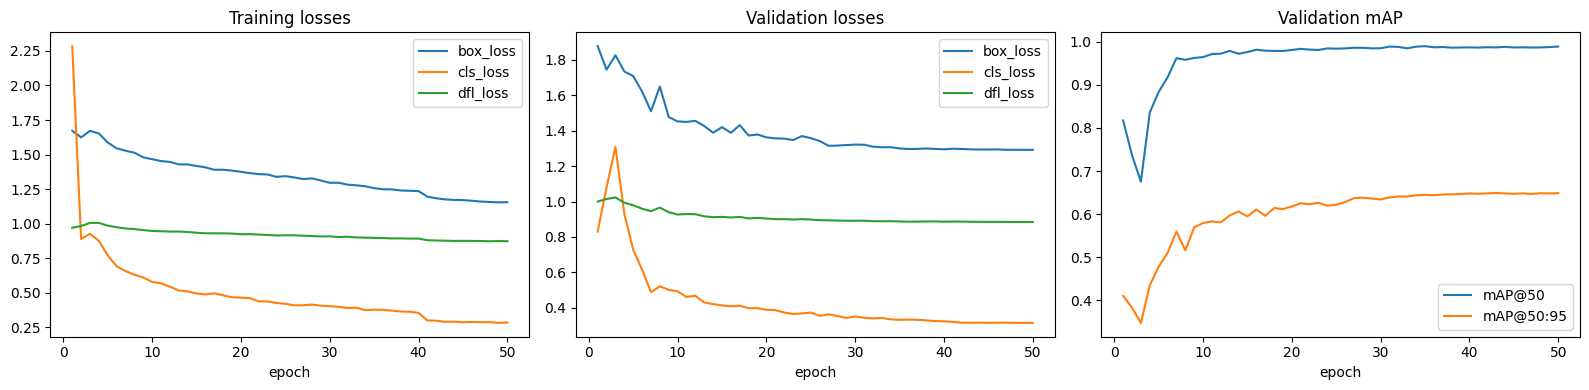

Best epoch 43: mAP@50=0.9869 | mAP@50:95=0.6492


In [6]:
# ---- training curves (loss + mAP), read from ultralytics' results.csv ------
res = pd.read_csv(Path(RUNS_DIR) / RUN_NAME / "results.csv")
res.columns = [c.strip() for c in res.columns]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c in ["train/box_loss", "train/cls_loss", "train/dfl_loss"]:
    if c in res: ax[0].plot(res["epoch"], res[c], label=c.split("/")[1])
ax[0].set_title("Training losses"); ax[0].set_xlabel("epoch"); ax[0].legend()

for c in ["val/box_loss", "val/cls_loss", "val/dfl_loss"]:
    if c in res: ax[1].plot(res["epoch"], res[c], label=c.split("/")[1])
ax[1].set_title("Validation losses"); ax[1].set_xlabel("epoch"); ax[1].legend()

for c, lb in [("metrics/mAP50(B)", "mAP@50"), ("metrics/mAP50-95(B)", "mAP@50:95")]:
    if c in res: ax[2].plot(res["epoch"], res[c], label=lb)
ax[2].set_title("Validation mAP"); ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout(); plt.show()

bi = res["metrics/mAP50-95(B)"].idxmax()
print(f"Best epoch {int(res.loc[bi,'epoch'])}: "
      f"mAP@50={res.loc[bi,'metrics/mAP50(B)']:.4f} | "
      f"mAP@50:95={res.loc[bi,'metrics/mAP50-95(B)']:.4f}")
# Viva prep: describe the curve shape here — e.g. whether val mAP is still
# rising at epoch 50 (=> more epochs could help) or flat after close_mosaic.

## 5. Test-Split Evaluation — 

Inference on the **held-out test split only**. mAP is computed by the validator sweeping confidence thresholds; the fixed operating point `conf=0.25` is used for the deployable Precision/Recall/F1 numbers and for error analysis.

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv10s summary (fused): 106 layers, 7,220,322 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 12.6±5.5 MB/s, size: 92.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo/test/labels... 3091 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3091/3091 257.6it/s 12.0s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 194/194 7.6it/s 25.4s
                   all       3091       3092      0.984      0.978      0.987      0.647
                 Anafi        

,cls,P,R,F1,mAP50,mAP50_95
0,Anafi,0.9877,0.9822,0.9849,0.9944,0.6603
1,DJI_FPV,0.9965,0.9806,0.9885,0.9937,0.6821
2,DJI_Phantom,0.9838,0.9809,0.9823,0.9839,0.5781
3,EFT_E410S,0.9967,1.0000,0.9984,0.9950,0.8102
4,Mavic_Air,0.9753,0.9694,0.9724,0.9798,0.5894
5,Mavic_Enterprise,0.9619,0.9551,0.9585,0.9760,0.5592


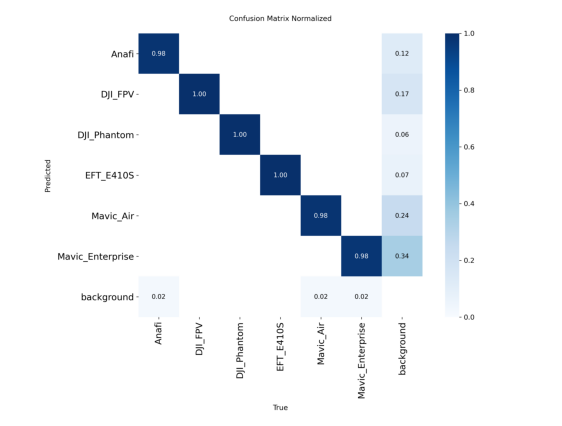

In [7]:
model = YOLO(str(BEST))
metrics = model.val(data=DATA_YAML, split="test", imgsz=IMG_SIZE, batch=BATCH,
                    project=RUNS_DIR, name="test_eval", exist_ok=True, plots=True)

mp, mr = metrics.box.mp, metrics.box.mr
f1 = 2 * mp * mr / (mp + mr + 1e-16)
print(f"TEST  mAP@50    : {metrics.box.map50:.4f}")
print(f"TEST  mAP@50:95 : {metrics.box.map:.4f}")
print(f"TEST  Precision : {mp:.4f}")
print(f"TEST  Recall    : {mr:.4f}")
print(f"TEST  F1        : {f1:.4f}")

# ---- per-class table (multi-class requirement) ------------------------------
rows = []
for i, ci in enumerate(metrics.box.ap_class_index):
    p, r, ap50, ap = metrics.box.class_result(i)
    rows.append(dict(cls=CLASS_NAMES[ci], P=p, R=r, F1=2*p*r/(p+r+1e-16),
                     mAP50=ap50, mAP50_95=ap))
per_class = pd.DataFrame(rows).round(4)
display(per_class)
per_class.to_csv("/kaggle/working/yolov10_per_class_metrics.csv", index=False)

# confusion matrix + PR curve saved by the validator:
for f in ["confusion_matrix_normalized.png", "PR_curve.png"]:
    p = Path(RUNS_DIR) / "test_eval" / f
    if p.exists():
        plt.figure(figsize=(7, 6)); plt.imshow(Image.open(p)); plt.axis("off"); plt.show()

In [8]:
# ---- inference speed (FPS) on the same hardware -----------------------------
test_imgs = sorted((DATASET_DIR / "test" / "images").iterdir())
bench = [str(p) for p in random.Random(SEED).sample(test_imgs, 300)]

_ = model.predict(bench[:10], imgsz=IMG_SIZE, conf=CONF_EVAL, verbose=False)  # warm-up
t0 = time.time()
for p in bench:
    model.predict(p, imgsz=IMG_SIZE, conf=CONF_EVAL, verbose=False)
wall = time.time() - t0
fps_e2e = len(bench) / wall

sp = metrics.speed  # ms/image from the batched validator run
fps_batched = 1000.0 / (sp["preprocess"] + sp["inference"] + sp["postprocess"])
print(f"End-to-end single-image FPS (incl. I/O): {fps_e2e:.1f}")
print(f"Batched validator FPS (pre+inf+post = "
      f"{sum(sp.values()):.1f} ms/img): {fps_batched:.1f}")
print("Note (viva): YOLOv10 is NMS-free, so postprocess time is near-zero — "
      "no NMS IoU threshold exists at inference.")

End-to-end single-image FPS (incl. I/O): 55.0
Batched validator FPS (pre+inf+post = 5.4 ms/img): 183.8
Note (viva): YOLOv10 is NMS-free, so postprocess time is near-zero — no NMS IoU threshold exists at inference.


## 6. Error Analysis — 

We match predictions (`conf=0.25`) to ground truth at IoU ≥ 0.5 per image:

* **FN** — GT box with no matching prediction (missed drone)
* **FP** — prediction with no matching GT box (ghost detection)
* **Misclassification** — IoU-matched pair with different class labels

Because Notebook 1 encoded `class_scenario` into every exported filename, we can also slice error rates **per lighting scenario** — Notebook 1 predicted *evening* as the dominant failure mode; this is where we test that claim.

In [9]:
def load_gt(lbl_path):
    boxes, cls = [], []
    txt = Path(lbl_path).read_text().strip()
    if txt:
        for ln in txt.splitlines():
            t = ln.split()
            if len(t) == 5:
                cls.append(int(t[0])); boxes.append(list(map(float, t[1:])))
    return np.array(boxes, dtype=float).reshape(-1, 4), np.array(cls, dtype=int)

def yolo_to_xyxy(b, W, H):  # (cx,cy,w,h) normalised -> pixel xyxy
    cx, cy, w, h = b[:, 0]*W, b[:, 1]*H, b[:, 2]*W, b[:, 3]*H
    return np.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], axis=1)

def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    tl = np.maximum(a[:, None, :2], b[None, :, :2])
    br = np.minimum(a[:, None, 2:], b[None, :, 2:])
    inter = np.clip(br - tl, 0, None).prod(-1)
    ar_a = (a[:, 2]-a[:, 0]) * (a[:, 3]-a[:, 1])
    ar_b = (b[:, 2]-b[:, 0]) * (b[:, 3]-b[:, 1])
    return inter / (ar_a[:, None] + ar_b[None, :] - inter + 1e-16)

def scenario_of(stem):
    for s in ["cloudy", "evening", "sunny"]:
        if f"_{s}_" in stem.lower(): return s
    return "unknown"

FN, FP, MISCLS = [], [], []
scen_stats = defaultdict(lambda: Counter())

for ip in test_imgs:
    lp = DATASET_DIR / "test" / "labels" / (ip.stem + ".txt")
    gt_n, gt_c = load_gt(lp)
    with Image.open(ip) as im: W, H = im.size
    gt_xy = yolo_to_xyxy(gt_n, W, H) if len(gt_n) else np.zeros((0, 4))

    r  = model.predict(str(ip), imgsz=IMG_SIZE, conf=CONF_EVAL, verbose=False)[0]
    pr_xy = r.boxes.xyxy.cpu().numpy() if r.boxes is not None else np.zeros((0, 4))
    pr_c  = r.boxes.cls.cpu().numpy().astype(int) if r.boxes is not None else np.array([], int)
    pr_cf = r.boxes.conf.cpu().numpy() if r.boxes is not None else np.array([])

    scen = scenario_of(ip.stem)
    scen_stats[scen]["gt"] += len(gt_xy)

    M = iou_matrix(gt_xy, pr_xy)
    g_used, p_used = set(), set()
    if M.size:
        for gi, pi in sorted(np.ndindex(M.shape), key=lambda x: -M[x]):
            if M[gi, pi] < 0.5 or gi in g_used or pi in p_used: continue
            g_used.add(gi); p_used.add(pi)
            if gt_c[gi] != pr_c[pi]:
                MISCLS.append(dict(img=ip, gt=CLASS_NAMES[gt_c[gi]],
                                   pred=CLASS_NAMES[pr_c[pi]], conf=pr_cf[pi],
                                   box=gt_xy[gi], scen=scen))
                scen_stats[scen]["miscls"] += 1
    for gi in range(len(gt_xy)):
        if gi not in g_used:
            area = (gt_xy[gi,2]-gt_xy[gi,0]) * (gt_xy[gi,3]-gt_xy[gi,1])
            FN.append(dict(img=ip, cls=CLASS_NAMES[gt_c[gi]], box=gt_xy[gi],
                           area=area, scen=scen))
            scen_stats[scen]["fn"] += 1
    for pi in range(len(pr_xy)):
        if pi not in p_used:
            FP.append(dict(img=ip, cls=CLASS_NAMES[pr_c[pi]], conf=pr_cf[pi],
                           box=pr_xy[pi], scen=scen))
            scen_stats[scen]["fp"] += 1

print(f"Test images: {len(test_imgs):,} | FN: {len(FN):,} | FP: {len(FP):,} "
      f"| misclassified (localised but wrong class): {len(MISCLS):,}")

scen_df = pd.DataFrame({s: dict(c) for s, c in scen_stats.items()}).T.fillna(0).astype(int)
scen_df["FN_rate"] = (scen_df["fn"] / scen_df["gt"]).round(3)
display(scen_df.sort_values("FN_rate", ascending=False))
print("^ Per-scenario slice — compare against Notebook 1's prediction that "
      "evening would be the dominant failure regime.")

Test images: 3,091 | FN: 64 | FP: 122 | misclassified (localised but wrong class): 0


,gt,fn,fp,FN_rate
evening,1041,36,63,0.035
sunny,1037,18,29,0.017
cloudy,1014,10,30,0.010


^ Per-scenario slice — compare against Notebook 1's prediction that evening would be the dominant failure regime.


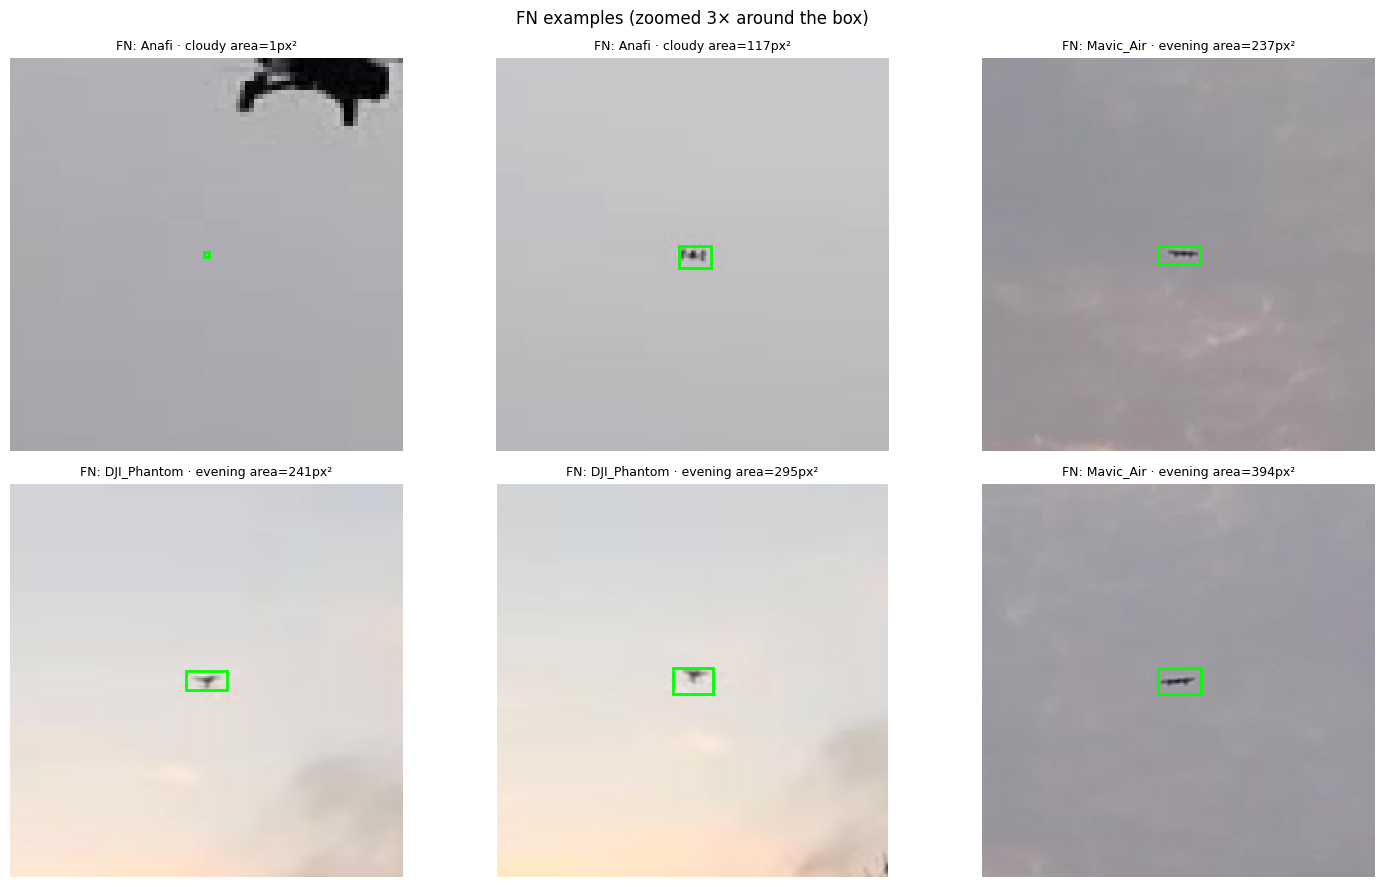

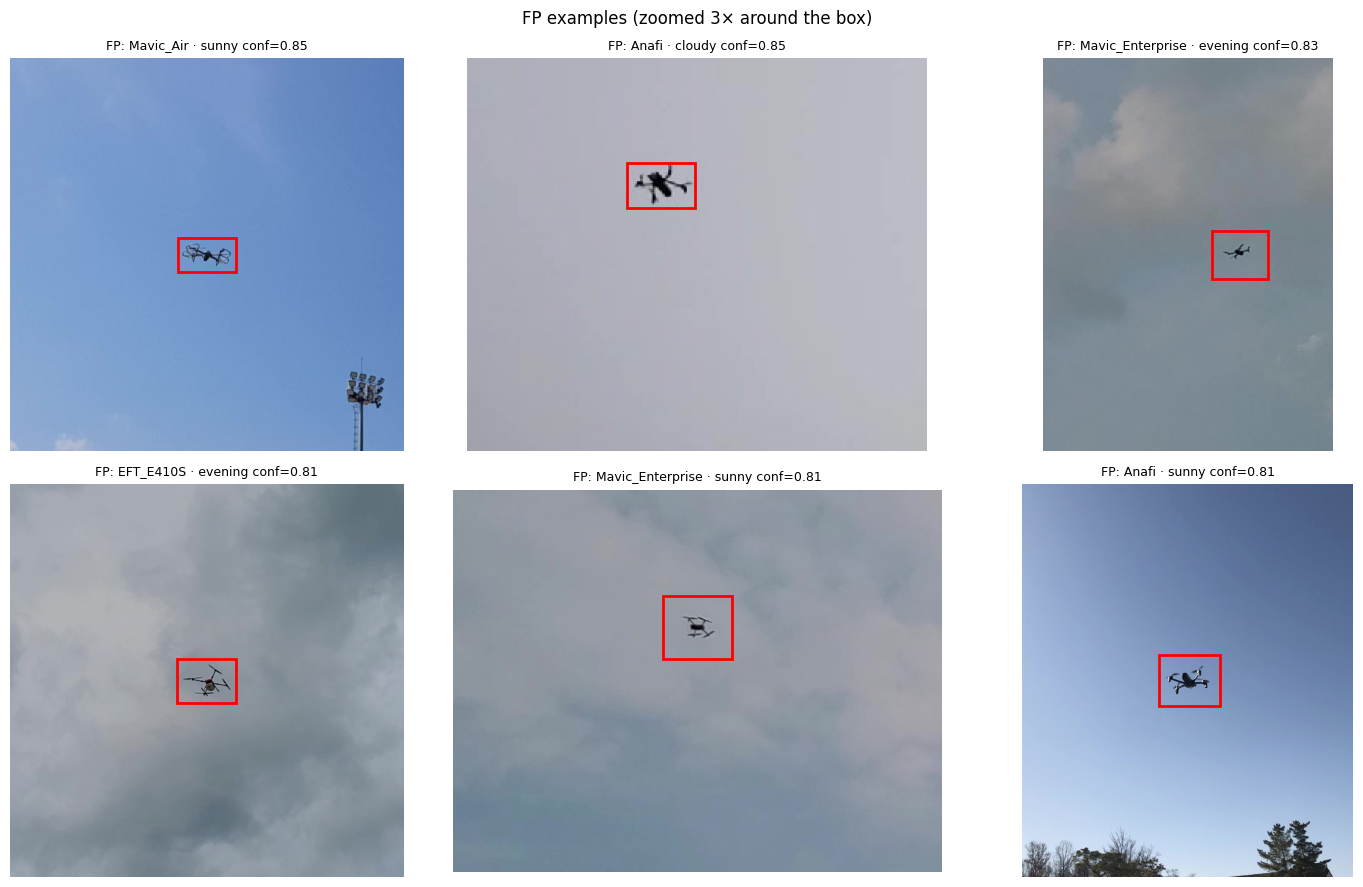

In [10]:
# ---- visualise >=3 FN and >=3 FP with GT (lime) / prediction (red) overlays --
def crop_context(box, W, H, pad=3.0):
    x1, y1, x2, y2 = box
    cx, cy = (x1+x2)/2, (y1+y2)/2
    s = max(x2-x1, y2-y1) * pad + 40
    return (max(0, cx-s), max(0, cy-s), min(W, cx+s), min(H, cy+s))

def show_cases(cases, kind, n=6):
    cases = cases[:n]
    if not cases:
        print(f"No {kind} cases at conf={CONF_EVAL} — lower conf to inspect near-misses.")
        return
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, c in zip(axes.ravel(), cases):
        im = Image.open(c["img"]).convert("RGB"); W, H = im.size
        ax.imshow(np.array(im.crop(crop_context(c["box"], W, H))))
        x1, y1, x2, y2 = c["box"]
        ox, oy, _, _ = crop_context(c["box"], W, H)
        col = "lime" if kind == "FN" else "red"
        ax.add_patch(mpatches.Rectangle((x1-ox, y1-oy), x2-x1, y2-y1,
                                        fill=False, edgecolor=col, lw=2))
        extra = f" conf={c['conf']:.2f}" if "conf" in c else f" area={c.get('area',0):.0f}px²"
        ax.set_title(f"{kind}: {c.get('cls','')} · {c['scen']}{extra}", fontsize=9)
        ax.set_axis_off()
    for ax in axes.ravel()[len(cases):]: ax.set_axis_off()
    fig.suptitle(f"{kind} examples (zoomed 3× around the box)"); plt.tight_layout(); plt.show()

# FNs sorted smallest-first (EDA says small boxes are the risk group); FPs by confidence
show_cases(sorted(FN, key=lambda c: c["area"]), "FN")
show_cases(sorted(FP, key=lambda c: -c["conf"]), "FP")
if MISCLS:
    show_cases(MISCLS, "MISCLS")

### 6.1 Written failure-pattern summary  *(fill in after inspecting the grids above)*

Replace the template below with what you actually observe — the viva probes these examples directly.

> **Dominant failure mode:** e.g. *False negatives concentrate in the `evening` scenario on boxes below ~1,500 px²: low contrast between a dark airframe and a dark sky removes the texture cues the backbone relies on. This matches Notebook 1's EDA prediction (photometric variation is the dataset's main axis) and its per-scenario stratification.*
>
> **FN causes (≥3 examples above):** small apparent size at high altitude / low contrast in evening frames / motion blur.
> **FP causes (≥3 examples above):** birds or distant aircraft with drone-like silhouettes / lens flare or cloud artifacts / duplicate-looking structures near the horizon.
> **Misclassifications:** typically between visually similar airframes (e.g. Mavic_Air ↔ Mavic_Enterprise) at small scales where the discriminating features (arm geometry, camera gimbal) are sub-pixel.
> **What would address it:** a 1280-imgsz fine-tune or tiled inference for small-object recall; stronger low-light photometric augmentation; raising `conf` to 0.4 if FPs dominate (report the P/R trade-off — viva Q6).

In [11]:
# ---- viva Q6: Precision/Recall trade-off when conf moves 0.25 -> 0.5 --------
sweep = []
for cf in [0.25, 0.40, 0.50]:
    m = model.val(data=DATA_YAML, split="test", imgsz=IMG_SIZE, batch=BATCH,
                  conf=cf, plots=False, verbose=False,
                  project=RUNS_DIR, name=f"sweep_conf{int(cf*100)}", exist_ok=True)
    sweep.append(dict(conf=cf, P=m.box.mp, R=m.box.mr,
                      F1=2*m.box.mp*m.box.mr/(m.box.mp+m.box.mr+1e-16)))
display(pd.DataFrame(sweep).round(4))
print("Raising conf discards low-confidence detections: Precision rises "
      "(fewer FPs) while Recall falls (borderline small drones dropped).")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 78.9±67.7 MB/s, size: 72.7 KB)
val: Scanning /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo/test/labels... 3091 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3091/3091 740.5it/s 4.2s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 194/194 8.9it/s 21.7s
                   all       3091       3092      0.984      0.978      0.981      0.641
Speed: 0.5ms preprocess, 4.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 106.5±83.6 MB/s, size: 99.1 KB)
val: Scanning /kaggle/in

,conf,P,R,F1
0,0.25,0.9836,0.9780,0.9808
1,0.40,0.9829,0.9788,0.9809
2,0.50,0.9855,0.9750,0.9802


Raising conf discards low-confidence detections: Precision rises (fewer FPs) while Recall falls (borderline small drones dropped).


## 7. Checkpoint Export & Handoff

Best weights are copied to a clearly named path in `/kaggle/working/` (assignment §6.2 step 8) so Notebooks 3–5 can reference this run for cross-model comparison. A machine-readable results summary is exported alongside.

In [12]:
CKPT_OUT = "/kaggle/working/yolov10m_visiodect_best.pt"
shutil.copy2(BEST, CKPT_OUT)

summary = dict(
    model="YOLOv10-m", weights=os.path.basename(CKPT_OUT),
    epochs_run=int(res["epoch"].max()), imgsz=IMG_SIZE, batch=BATCH, seed=SEED,
    test_mAP50=round(float(metrics.box.map50), 4),
    test_mAP50_95=round(float(metrics.box.map), 4),
    test_precision=round(float(mp), 4), test_recall=round(float(mr), 4),
    test_F1=round(float(f1), 4),
    fps_end_to_end=round(fps_e2e, 1), fps_batched=round(fps_batched, 1),
    fn=len(FN), fp=len(FP), misclassified=len(MISCLS),
)
Path("/kaggle/working/yolov10_results.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

print("\n--- /kaggle/working ---")
for p in sorted(Path("/kaggle/working").iterdir()):
    print(" ", p.name)
print("\nNEXT: Save Version (commit) -> verify all outputs visible -> set Public -> "
      "post the link. Reuse this notebook's structure for YOLOv12 (NB3) and v26 (NB4).")

{
  "model": "YOLOv10-m",
  "weights": "yolov10m_visiodect_best.pt",
  "epochs_run": 50,
  "imgsz": 640,
  "batch": 16,
  "seed": 42,
  "test_mAP50": 0.9871,
  "test_mAP50_95": 0.6466,
  "test_precision": 0.9836,
  "test_recall": 0.978,
  "test_F1": 0.9808,
  "fps_end_to_end": 55.0,
  "fps_batched": 183.8,
  "fn": 64,
  "fp": 122,
  "misclassified": 0
}

--- /kaggle/working ---
  __notebook__.ipynb
  data.yaml
  runs
  yolo26n.pt
  yolov10_per_class_metrics.csv
  yolov10_results.json
  yolov10m_visiodect_best.pt
  yolov10s.pt

NEXT: Save Version (commit) -> verify all outputs visible -> set Public -> post the link. Reuse this notebook's structure for YOLOv12 (NB3) and v26 (NB4).


### Handoff checklist 
- [ ] Dry-run extrapolation printed and fits the session budget
- [ ] Full 50-epoch run completed with loss + mAP curves visible
- [ ] Test metrics table (overall + per-class) and FPS printed
- [ ] ≥3 FN and ≥3 FP grids rendered, failure summary **written in your own words**
- [ ] `yolov10m_visiodect_best.pt` + `yolov10_results.json` present in `/kaggle/working/`
- [ ] Notebook Public, link tested in incognito, group info filled in